# Лабораторная работа 2

## Инкин Артем Игоревич, 6401-010302D
## Вариант 3

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [3]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [5]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()

print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [6]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [7]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


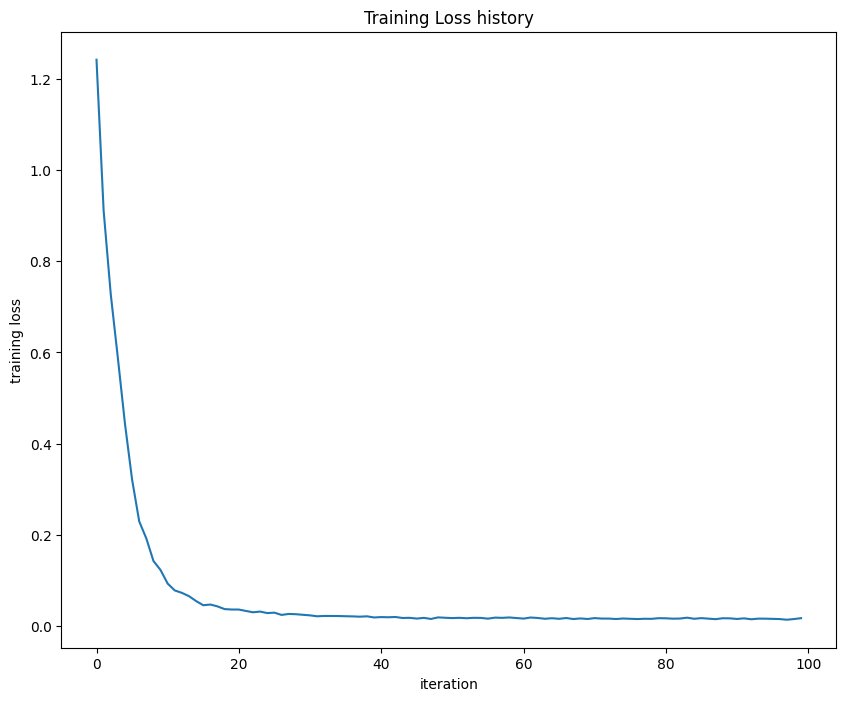

In [9]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [10]:
from scripts.data_utils import load_CIFAR10

cifar10_dir = 'scripts/datasets/cifar-10-batches-py'
X_train_full, y_train_full, X_test_full, y_test_full = load_CIFAR10(cifar10_dir)

num_training = 49000
num_validation = 1000
num_test = 1000

mask = list(range(num_training, num_training + num_validation))
X_val = X_train_full[mask]
y_val = y_train_full[mask]

mask = list(range(num_training))
X_train = X_train_full[mask]
y_train = y_train_full[mask]

mask = list(range(num_test))
X_test = X_test_full[mask]
y_test = y_test_full[mask]

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

mean_image = np.mean(X_train, axis=0)
X_train = X_train.astype(np.float64) - mean_image
X_val = X_val.astype(np.float64) - mean_image
X_test = X_test.astype(np.float64) - mean_image

print('Обучающая:', X_train.shape)
print('Валидационная:', X_val.shape)
print('Тестовая:', X_test.shape)

Обучающая: (49000, 3072)
Валидационная: (1000, 3072)
Тестовая: (1000, 3072)


In [11]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302954
iteration 100 / 1000: loss 2.302550
iteration 200 / 1000: loss 2.297648
iteration 300 / 1000: loss 2.259602
iteration 400 / 1000: loss 2.204170
iteration 500 / 1000: loss 2.118565
iteration 600 / 1000: loss 2.051535
iteration 700 / 1000: loss 1.988466
iteration 800 / 1000: loss 2.006591
iteration 900 / 1000: loss 1.951473
Validation accuracy:  0.287


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

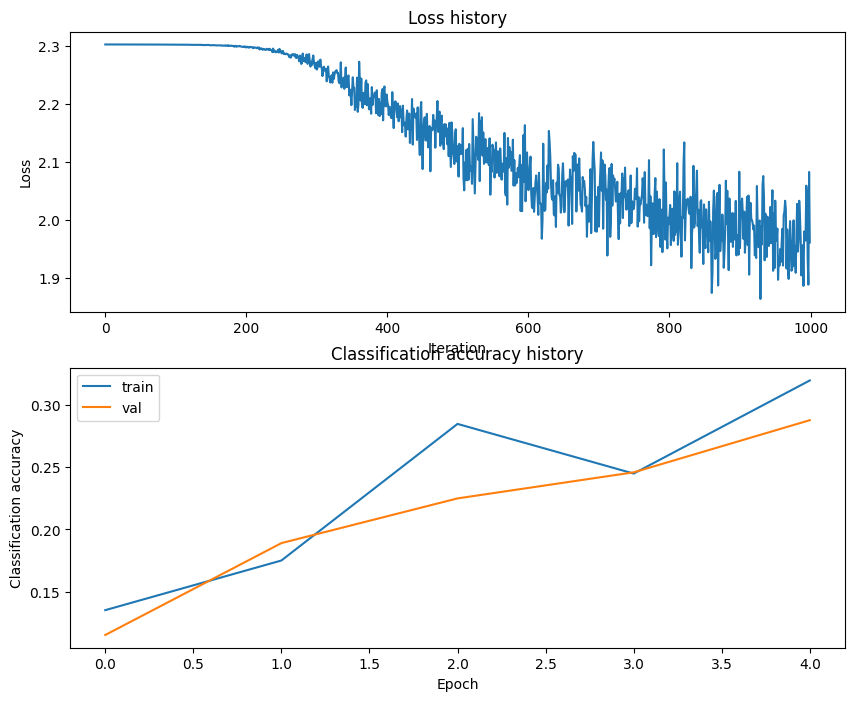

In [12]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

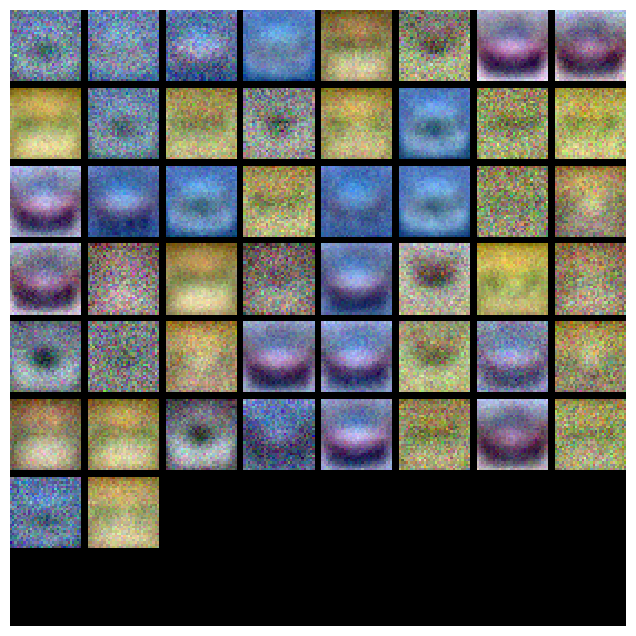

In [13]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

In [18]:
best_net = None
best_val_acc = 0
best_params = {}
best_stats = None

learning_rates = [5e-4, 1e-3]
hidden_sizes = [100, 200]
regs = [0.1, 0.25]

for lr in learning_rates:
    for hs in hidden_sizes:
        for reg in regs:
            net_tmp = TwoLayerNet(input_size, hs, num_classes)
            tmp_stats = net_tmp.train(X_train, y_train, X_val, y_val,
                          num_iters=2000, batch_size=200,
                          learning_rate=lr, learning_rate_decay=0.95,
                          reg=reg, verbose=False)
            acc = (net_tmp.predict(X_val) == y_val).mean()
            print('lr=%.0e, hidden=%d, reg=%.2f -> val acc=%.3f' % (lr, hs, reg, acc))
            if acc > best_val_acc:
                best_val_acc = acc
                best_net = net_tmp
                best_stats = tmp_stats
                best_params = {'lr': lr, 'hidden': hs, 'reg': reg}

print('\nЛучшие параметры:', best_params)
print('Лучшая точность на валидации: %.3f' % best_val_acc)

lr=5e-04, hidden=100, reg=0.10 -> val acc=0.486
lr=5e-04, hidden=100, reg=0.25 -> val acc=0.478
lr=5e-04, hidden=200, reg=0.10 -> val acc=0.499
lr=5e-04, hidden=200, reg=0.25 -> val acc=0.469
lr=1e-03, hidden=100, reg=0.10 -> val acc=0.503
lr=1e-03, hidden=100, reg=0.25 -> val acc=0.514
lr=1e-03, hidden=200, reg=0.10 -> val acc=0.514
lr=1e-03, hidden=200, reg=0.25 -> val acc=0.524

Лучшие параметры: {'lr': 0.001, 'hidden': 200, 'reg': 0.25}
Лучшая точность на валидации: 0.524


In [20]:
test_acc = (best_net.predict(X_test) == y_test).mean()
print('Точность на тесте: %.3f' % test_acc)

Точность на тесте: 0.514


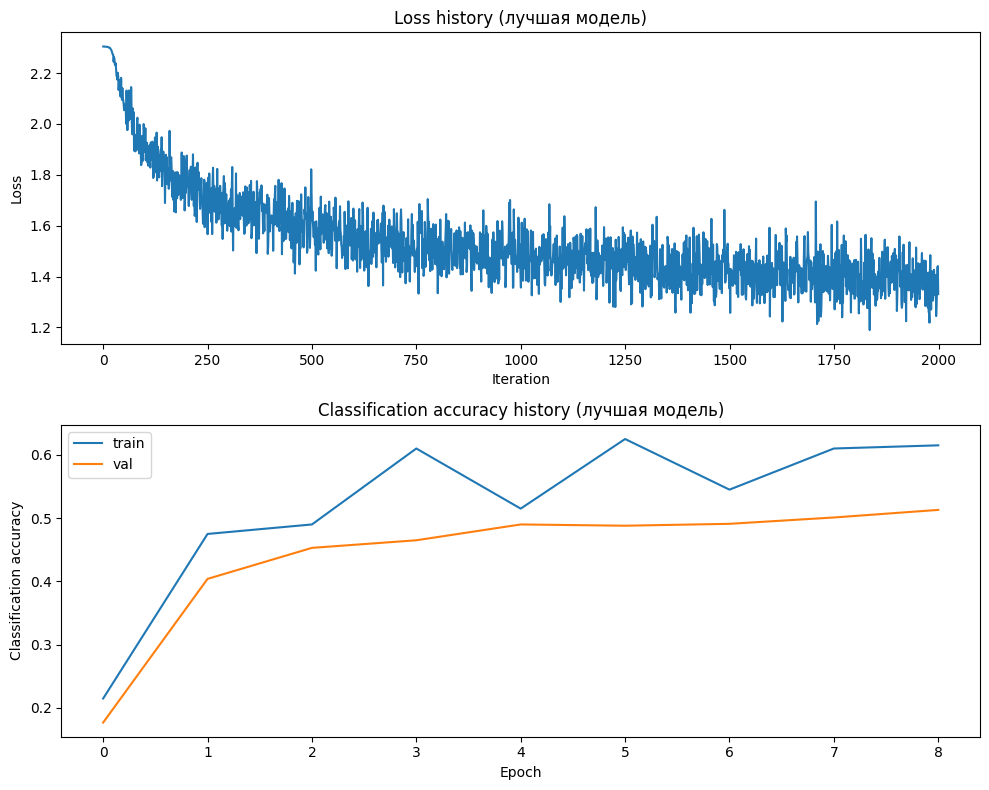

In [21]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history (лучшая модель)')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history (лучшая модель)')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.tight_layout()
plt.show()

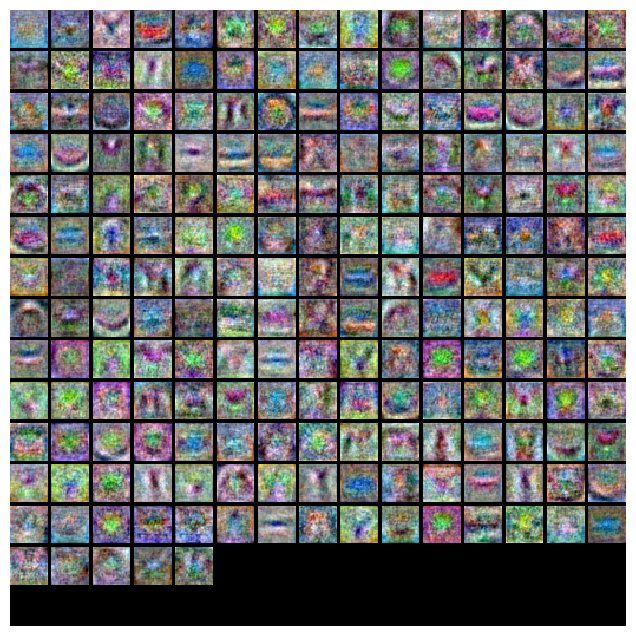

In [22]:
show_net_weights(best_net)

Сделайте выводы по результатам работы. 

Нейронная сеть обучалась на наборе данных CIFAR-10 (49000 обучающих, 1000 валидационных, 1000 тестовых примеров). Предобработка: изображения разворачивались в вектор 3072 признаков, затем вычиталось среднее изображение по обучающей выборке.

Дефолтная сеть (hidden=50, lr=1e-4, reg=0.25, 1000 итераций) показала точность 28.7% на валидации. Loss падал с 2.30 до 1.95, что говорит о нормальной сходимости, но медленной - первые 200 итераций сеть почти не обучалась.

После перебора гиперпараметров лучшей оказалась конфигурация lr=0.001, hidden=200, reg=0.25 с точностью 52.4% на валидации и 51.4% на тесте. Это почти вдвое лучше дефолтной модели и заметно выше результатов из ЛР1 - kNN давал 28.2%, Softmax 34.6%.

Из экспериментов видно что большая скорость обучения (lr=1e-3 против 5e-4) даёт стабильный прирост точности во всех конфигурациях. Увеличение скрытого слоя со 100 до 200 нейронов тоже помогает, хотя прирост меньше. На графике лучшей модели заметен разрыв между train (~60%) и val (~50%), что говорит о переобучении - сеть без dropout и с двумя слоями имеет ограниченную способность к обобщению.